   Study_Hours  Attendance Result
0            2          60   Fail
1            3          70   Fail
2            1          50   Fail
3            5          80   Pass
4            6          85   Pass

Dataset Info:
       Study_Hours  Attendance
count    20.000000   20.000000
mean      4.400000   74.000000
std       2.233713   15.061278
min       1.000000   45.000000
25%       2.750000   63.750000
50%       4.500000   75.500000
75%       6.000000   85.750000
max       8.000000   96.000000

Value Counts for Result:
Result
Pass    12
Fail     8
Name: count, dtype: int64


/tmp/ipykernel_7910/1592532563.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Result', y='Study_Hours', data=df, ax=axes[1], palette='Set2')
/tmp/ipykernel_7910/1592532563.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Result', y='Attendance', data=df, ax=axes[2], palette='Set1')


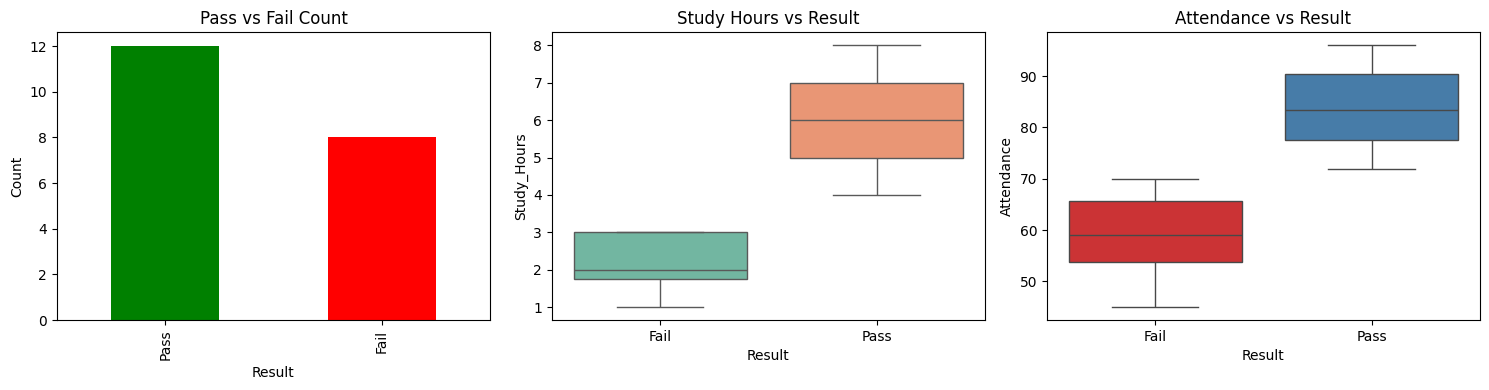

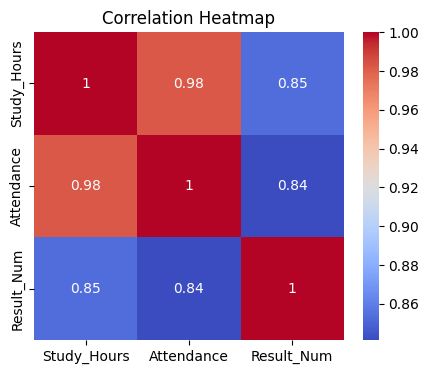


Prediction for 6 hrs study, 75% attendance: Pass
Probability of Fail: 0.01
Probability of Pass: 0.99

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



In [ ]:
# Task 1: Logistic Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Create Dataset (20 records)
data = {
    'Study_Hours': [2, 3, 1, 5, 6, 4, 7, 2, 8, 3, 5, 6, 1, 4, 7, 3, 6, 5, 2, 8],
    'Attendance':  [60, 70, 50, 80, 85, 75, 90, 55, 95, 65, 78, 88, 45, 72, 92, 68, 82, 76, 58, 96],
    'Result':      ['Fail','Fail','Fail','Pass','Pass','Pass','Pass','Fail','Pass','Fail',
                    'Pass','Pass','Fail','Pass','Pass','Fail','Pass','Pass','Fail','Pass']
}

df = pd.DataFrame(data)
print(df.head())

# Step 2: EDA
print("\nDataset Info:")
print(df.describe())
print("\nValue Counts for Result:")
print(df['Result'].value_counts())

# EDA Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Count of Pass/Fail
df['Result'].value_counts().plot(kind='bar', ax=axes[0], color=['green','red'])
axes[0].set_title('Pass vs Fail Count')
axes[0].set_xlabel('Result')
axes[0].set_ylabel('Count')

# Plot 2: Study Hours vs Result
sns.boxplot(x='Result', y='Study_Hours', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Study Hours vs Result')

# Plot 3: Attendance vs Result
sns.boxplot(x='Result', y='Attendance', data=df, ax=axes[2], palette='Set1')
axes[2].set_title('Attendance vs Result')

plt.tight_layout()
plt.savefig('task1_eda.png', dpi=150)
plt.show()

# Correlation Heatmap
df['Result_Num'] = df['Result'].map({'Pass': 1, 'Fail': 0})
plt.figure(figsize=(5, 4))
sns.heatmap(df[['Study_Hours','Attendance','Result_Num']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('task1_heatmap.png', dpi=150)
plt.show()

# Step 3: Encode + Train Model
X = df[['Study_Hours', 'Attendance']]
y = df['Result_Num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

# Step 4: Predict for new student (6 hours, 75% attendance)
new_student = pd.DataFrame({'Study_Hours': [6], 'Attendance': [75]})
prediction = model.predict(new_student)
probability = model.predict_proba(new_student)

print(f"\nPrediction for 6 hrs study, 75% attendance: {'Pass' if prediction[0]==1 else 'Fail'}")
print(f"Probability of Fail: {probability[0][0]:.2f}")
print(f"Probability of Pass: {probability[0][1]:.2f}")

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test)))

   Experience Performance_Rating Promotion
0           1                Low        No
1           2                Low        No
2           3             Medium        No
3           5               High       Yes
4           6               High       Yes

Promotion Value Counts:
Promotion
Yes    11
No      9
Name: count, dtype: int64

Performance Rating Counts:
Performance_Rating
High      8
Low       6
Medium    6
Name: count, dtype: int64


/tmp/ipykernel_7910/3210380426.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Promotion', y='Experience', data=df2, ax=axes[1], palette='Set3')


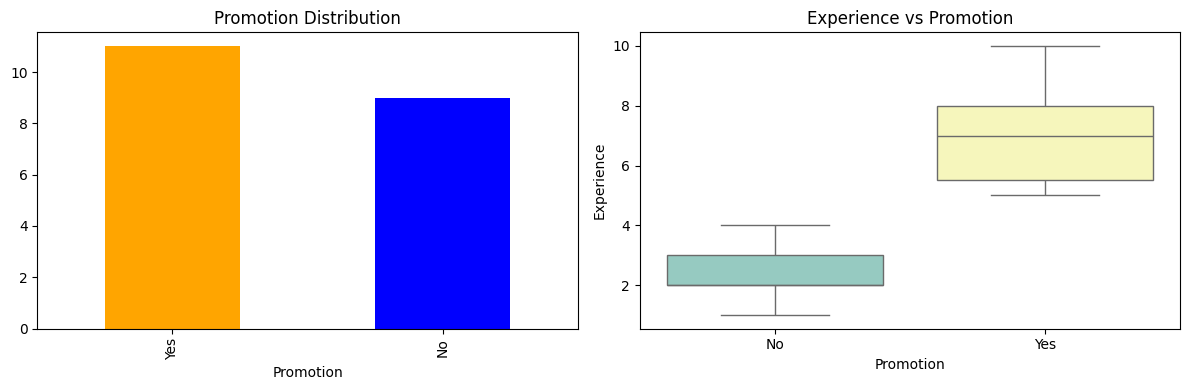


Encoding - Performance: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Encoding - Promotion: {'No': np.int64(0), 'Yes': np.int64(1)}


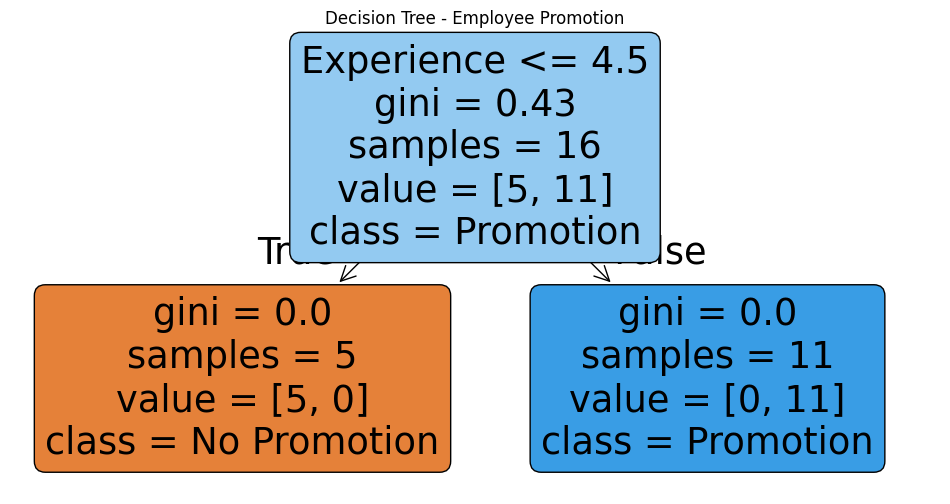


Prediction for 5 yrs exp, High performance: Yes
Probability of No Promotion: 0.00
Probability of Promotion: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [ ]:
# Task 2: Decision Tree Classifier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import seaborn as sns

# Step 1: Create Dataset
data2 = {
    'Experience': [1, 2, 3, 5, 6, 7, 8, 2, 4, 9, 10, 3, 6, 5, 7, 1, 8, 4, 2, 5],
    'Performance_Rating': ['Low','Low','Medium','High','High','Medium','High','Low',
                           'Medium','High','High','Low','Medium','High','High','Low',
                           'High','Medium','Low','Medium'],
    'Promotion': ['No','No','No','Yes','Yes','Yes','Yes','No','No','Yes','Yes',
                  'No','Yes','Yes','Yes','No','Yes','No','No','Yes']
}

df2 = pd.DataFrame(data2)
print(df2.head())

# Step 2: EDA
print("\nPromotion Value Counts:")
print(df2['Promotion'].value_counts())
print("\nPerformance Rating Counts:")
print(df2['Performance_Rating'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Promotion Count
df2['Promotion'].value_counts().plot(kind='bar', ax=axes[0], color=['orange','blue'])
axes[0].set_title('Promotion Distribution')

# Plot 2: Experience vs Promotion
sns.boxplot(x='Promotion', y='Experience', data=df2, ax=axes[1], palette='Set3')
axes[1].set_title('Experience vs Promotion')

plt.tight_layout()
plt.savefig('task2_eda.png', dpi=150)
plt.show()

# Step 3: Encode Categorical Variables
le_perf = LabelEncoder()
le_promo = LabelEncoder()

df2['Performance_Encoded'] = le_perf.fit_transform(df2['Performance_Rating'])  # High=0, Low=1, Medium=2
df2['Promotion_Encoded'] = le_promo.fit_transform(df2['Promotion'])             # No=0, Yes=1

print("\nEncoding - Performance:", dict(zip(le_perf.classes_, le_perf.transform(le_perf.classes_))))
print("Encoding - Promotion:", dict(zip(le_promo.classes_, le_promo.transform(le_promo.classes_))))

X2 = df2[['Experience', 'Performance_Encoded']]
y2 = df2['Promotion_Encoded']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train2, y_train2)

# Visualize Tree
plt.figure(figsize=(12, 6))
plot_tree(dt_model,
          feature_names=['Experience', 'Performance_Rating'],
          class_names=['No Promotion', 'Promotion'],
          filled=True, rounded=True)
plt.title('Decision Tree - Employee Promotion')
plt.savefig('task2_tree.png', dpi=150)
plt.show()

# Step 4: Predict for 5 years experience, High performance
# High is encoded as 0 by LabelEncoder
high_encoded = le_perf.transform(['High'])[0]
new_employee = pd.DataFrame({'Experience': [5], 'Performance_Encoded': [high_encoded]})
promo_pred = dt_model.predict(new_employee)
promo_prob = dt_model.predict_proba(new_employee)

result = le_promo.inverse_transform(promo_pred)
print(f"\nPrediction for 5 yrs exp, High performance: {result[0]}")
print(f"Probability of No Promotion: {promo_prob[0][0]:.2f}")
print(f"Probability of Promotion: {promo_prob[0][1]:.2f}")

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test2, dt_model.predict(X_test2)))